In [1]:
# # SwinUNet3D - Segmentation 3D avec Transformers d'une base de donnée de 35 patient d'entrainement

# 1. Monte Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install --force-reinstall numpy monai einops timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/89

In [2]:
# 2. Installation des dépendances
import os
import glob
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from monai.utils import first, set_determinism
from monai.data import Dataset, DataLoader, CacheDataset, decollate_batch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld,
    RandAffined, AsDiscrete, AsDiscreted, Invertd, SaveImaged
)
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference

import einops
from einops.layers.torch import Rearrange


In [3]:
# 3. Configuration des chemins
dossier_path = '/content/drive/MyDrive/Nouveau/Lung250M_4B/Lung250M_4B'
# 3 Lister les fichiers dans le dossier
fichiers = os.listdir(dossier_path)
print("Fichiers dans le dossier :", fichiers)

%matplotlib inline
images_train = sorted(glob.glob(os.path.join(dossier_path, "imagesTr", "*.nii.gz")))
labels_train = sorted(glob.glob(os.path.join(dossier_path, "masksTr", "*.nii.gz")))
images_test = sorted(glob.glob(os.path.join(dossier_path, "imagesTs", "*.nii.gz")))
labels_test = sorted(glob.glob(os.path.join(dossier_path, "masksTs", "*.nii.gz")))

print(f'Nombre d\'images train: {len(images_train)}, test: {len(images_test)}')

Fichiers dans le dossier : ['imagesTr', 'imagesTs', 'masksTs', 'masksTr']
Nombre d'images train: 42, test: 30


In [4]:
# 4. Définition des transformations optimisées
def get_train_transforms():
    return Compose([
        LoadImaged(keys=["image", "label"], reader="NibabelReader"),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest")),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            pos=1,
            neg=1,
            num_samples=4,
            image_key="image",
            image_threshold=0,
        ),
        RandAffined(
            keys=['image', 'label'],
            mode=('bilinear', 'nearest'),
            prob=1.0,
            spatial_size=(96, 96, 96),
            rotate_range=(0, 0, np.pi/15),
            scale_range=(0.1, 0.1, 0.1),
        ),
    ])

def get_val_transforms():
    return Compose([
        LoadImaged(keys=["image", "label"], reader="NibabelReader"),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest")),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
        CropForegroundd(keys=["image", "label"], source_key="image"),
    ])

train_transforms = get_train_transforms()
val_transforms = get_val_transforms()
test_transforms = get_val_transforms()


/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [5]:
# 5. Préparation des données
train_data_dicts = [{"image": img, "label": lbl} for img, lbl in zip(images_train, labels_train)]
test_data_dicts = [{"image": img, "label": lbl} for img, lbl in zip(images_test, labels_test)]

np.random.shuffle(train_data_dicts)
train_split = int(0.85 * len(train_data_dicts))
train_files = train_data_dicts[:train_split]
val_files = train_data_dicts[train_split:]

train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=1.0,
    num_workers=4
)
val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=1.0,
    num_workers=2
)
test_ds = CacheDataset(
    data=test_data_dicts,
    transform=test_transforms,
    cache_rate=1.0,
    num_workers=2
)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2
)
val_loader = DataLoader(
    val_ds,
    batch_size=1,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=1,
    num_workers=2,
    pin_memory=True
)

print(f"Entraînement : {len(train_files)} fichiers")
print(f"Validation : {len(val_files)} fichiers")
print(f"Test : {len(test_data_dicts)} fichiers")


Loading dataset: 100%|██████████| 30/30 [01:48<00:00,  3.63s/it]

Entraînement : 35 fichiers
Validation : 7 fichiers
Test : 30 fichiers



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [6]:
# 3. Créer une liste de dictionnaires pour les données de test
test_files = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(images_test, labels_test)
]

# 4. Afficher le nombre de fichiers dans chaque ensemble
print(f"Entraînement : {len(train_files)} fichiers")
print(f"Validation : {len(val_files)} fichiers")
print(f"Test : {len(test_files)} fichiers")

Entraînement : 35 fichiers
Validation : 7 fichiers
Test : 30 fichiers


In [7]:
# code adapté du projet : https://github.com/1152545264/SwinUnet3D/tree/master
# Les importation
import torch
from torch import nn, einsum
import torch.nn.functional as F # Import pour le padding
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from typing import Union, List
import numpy as np
from timm.models.layers import trunc_normal_


class CyclicShift3D(nn.Module): # Décale cycliquement les volumes 3D
    def __init__(self, displacement):
        super().__init__()
        # displacement correspond à combien on déplace dans chaque axe
        assert type(displacement) is int or len(displacement) == 3, f'displacement must be 1 or 3 dimension'
        if type(displacement) is int:
            displacement = np.array([displacement, displacement, displacement])
        self.displacement = displacement

    def forward(self, x):
        # torch.roll est utilisé pour décaler cycliquement les élements d'un tenseur.
        # x est l'entrée du modèle c'est à dire le tenseur que sera traité.
        # shifts = décalage sur chaque dimensions et dims=(1,2,3) signifie que les 3 dimension seront traité
        return torch.roll(x, shifts=(self.displacement[0], self.displacement[1], self.displacement[2]), dims=(1, 2, 3))


class Residual3D(nn.Module): #permet d'ajouter une connexion résiduelle dans un réseau 3D
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x


class PreNorm3D(nn.Module): #pour appliquer une normalisation sur les entrées avant de passer à une transformation
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward3D(nn.Module): # transforme les données en passant par 2 couches avec une activation entre elles
    def __init__(self, dim, hidden_dim, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim), # première couche pour transformer l'entrée de taille dim en hidden_dim
            nn.GELU(), # dans les transformers, GELU donne de meilleur performance que RELU
            nn.Linear(hidden_dim, dim), # deuxième couche pour ramener à la dimension d'origine(dim)
        )
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity() # pour éviter le surapprentissage avec un taux = dropout

    def forward(self, x):
        x = self.net(x)
        x = self.drop(x)
        return x


def create_mask3D(window_size: Union[int, List[int]], displacement: Union[int, List[int]], x_shift: bool, y_shift: bool, z_shift: bool):
    # cette fonction crée un masque 3D pour bloquer l'attention entre certaines positions dans un espace 3D.
    assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'  #vérifie que la taille du cube est un entier et liste de 3 entier
    if type(window_size) is int:
        window_size = np.array([window_size, window_size, window_size])

    assert type(displacement) is int or len(displacement) == 3, f'displacement must be 1 or 3 dimension'
    if type(displacement) is int:
        displacement = np.array([displacement, displacement, displacement])

    assert len(window_size) == len(displacement)
    for i in range(len(window_size)):
        assert 0 < displacement[i] < window_size[i], f'Décalage invalide sur l’axe {i} — les axes sont X(i=0), Y(i=1), Z(i=2)'

    mask = torch.zeros(window_size[0] * window_size[1] * window_size[2], window_size[0] * window_size[1] * window_size[2])  # (wx*wy*wz, wx*wy*wz)
    mask = rearrange(mask, '(x1 y1 z1) (x2 y2 z2) -> x1 y1 z1 x2 y2 z2', x1=window_size[0], y1=window_size[1], x2=window_size[0], y2=window_size[1])

    x_dist, y_dist, z_dist = displacement[0], displacement[1], displacement[2]

    if x_shift:
        #      x1     y1 z1     x2     y2 z2
        mask[-x_dist:, :, :, :-x_dist, :, :] = float('-inf')
        mask[:-x_dist, :, :, -x_dist:, :, :] = float('-inf')

    if y_shift:
        #   x1   y1       z1 x2  y2       z2
        mask[:, -y_dist:, :, :, :-y_dist, :] = float('-inf')
        mask[:, :-y_dist, :, :, -y_dist:, :] = float('-inf')

    if z_shift:
        #   x1  y1  z1       x2 y2  z2
        mask[:, :, -z_dist:, :, :, :-z_dist] = float('-inf')
        mask[:, :, :-z_dist, :, :, -z_dist:] = float('-inf')

    mask = rearrange(mask, 'x1 y1 z1 x2 y2 z2 -> (x1 y1 z1) (x2 y2 z2)')
    return mask


def get_relative_distances(window_size):  # cette fonction calcule les distances entre chaque voxel dans un cube 3D
    assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
    if type(window_size) is int:
        window_size = np.array([window_size, window_size, window_size])
    indices = torch.tensor( np.array([[x, y, z] for x in range(window_size[0]) for y in range(window_size[1]) for z in range(window_size[2])])) # crée toutes les positions 3D dans la fenêtre

    distances = indices[None, :, :] - indices[:, None, :] #pour chaque paire de positions, calcule la diffèrence [dx,dy,dz]
    # distance:(n,n,3) n =window_size[0]*window_size[1]*window_size[2]
    return distances


class WindowAttention3D(nn.Module):
    #but de la classe : faire de l'attention dans  un cube 3D, fenetré et parfois décalé pour capturer plus de contexte local
    def __init__(self, dim: int, heads: int, head_dim: int, shifted: bool, window_size: Union[int, List[int]], relative_pos_embedding: bool = True):
        super().__init__()

        assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
        if type(window_size) is int:
            window_size = np.array([window_size, window_size, window_size]) #on crée un cube
        else:
            window_size = np.array(window_size)

        inner_dim = head_dim * heads
        self.heads = heads
        self.scale = head_dim ** -0.5
        self.window_size = window_size
        self.shifted = shifted

        if self.shifted:
            displacement = window_size // 2
            self.cyclic_shift = CyclicShift3D(-displacement)
            self.cyclic_back_shift = CyclicShift3D(displacement)
            self.x_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=True, y_shift=False, z_shift=False), requires_grad=False)
            self.y_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=False, y_shift=True, z_shift=False), requires_grad=False)
            self.z_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=False, y_shift=False, z_shift=True), requires_grad=False)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)  #génération de QKV chacun ayant la même dimension.


        self.softmax = nn.Softmax(dim=-1) #transforme un vecteur de score en probabilités et dim=-1 signifie que la normalisation va se faire sur la dernière dimension de chaque vecteur
        self.to_out = nn.Linear(inner_dim, dim)

    def forward(self, x):
        if self.shifted:
            x = self.cyclic_shift(x)

        b, n_x, n_y, n_z, _, h = *x.shape, self.heads

        qkv = self.to_qkv(x).chunk(3, dim=-1)
        nw_x = n_x // self.window_size[0]
        nw_y = n_y // self.window_size[1]
        nw_z = n_z // self.window_size[2]

        q, k, v = map(
            lambda t: rearrange(t, 'b (nw_x w_x) (nw_y w_y) (nw_z w_z) (h d) -> b h (nw_x nw_y nw_z) (w_x w_y w_z) d',
                                h=h, w_x=self.window_size[0], w_y=self.window_size[1], w_z=self.window_size[2]), qkv)

        dots = einsum('b h w i d, b h w j d -> b h w i j', q, k) * self.scale  # Produit scalaire entre q et k pour obtenir les scores d'attention

        if self.shifted:
            dots = rearrange(dots, 'b h (n_x n_y n_z) i j -> b h n_y n_z n_x i j',
                             n_x=nw_x, n_y=nw_y)
            dots[:, :, :, :, -1] += self.x_mask

            dots = rearrange(dots, 'b h n_y n_z n_x i j -> b h n_x n_z n_y i j')
            dots[:, :, :, :, -1] += self.y_mask

            dots = rearrange(dots, 'b h n_x n_z n_y i j -> b h n_x n_y n_z i j')
            dots[:, :, :, :, -1] += self.z_mask

            dots = rearrange(dots, 'b h n_y n_z n_x i j -> b h (n_x n_y n_z) i j')


        attn = self.softmax(dots)
        out = einsum('b h w i j, b h w j d -> b h w i d', attn, v)
        out = rearrange(out, 'b h (nw_x nw_y nw_z) (w_x w_y w_z) d -> b (nw_x w_x) (nw_y w_y) (nw_z w_z) (h d)',
                        h=h, w_x=self.window_size[0], w_y=self.window_size[1], w_z=self.window_size[2],
                        nw_x=nw_x, nw_y=nw_y, nw_z=nw_z)
        out = self.to_out(out)

        if self.shifted:
            out = self.cyclic_back_shift(out)
        return out


class SwinBlock3D(nn.Module):  #capture les dépendances à longue distance dans les images 3D via une attention multi-têtes localisée
    def __init__(self, dim, heads, head_dim, mlp_dim, shifted, window_size: Union[int, List[int]],
                 relative_pos_embedding: bool = True, dropout: float = 0.0):
        super().__init__()
        self.attention_block = Residual3D(PreNorm3D(dim, WindowAttention3D(dim=dim,
                                                                           heads=heads,
                                                                           head_dim=head_dim,
                                                                           shifted=shifted,
                                                                           window_size=window_size,
                                                                           relative_pos_embedding=relative_pos_embedding)))
        self.mlp_block = Residual3D(PreNorm3D(dim, FeedForward3D(dim=dim, hidden_dim=mlp_dim, dropout=dropout)))

    def forward(self, x):
        x = self.attention_block(x)
        x = self.mlp_block(x)
        return x


class Norm(nn.Module): #normalisation sur les features
    def __init__(self, dim, channel_first: bool = True):
        super(Norm, self).__init__()
        if channel_first:
            self.net = nn.Sequential(
                Rearrange('b c h w d -> b h w d c'),
                nn.LayerNorm(dim),
                Rearrange('b h w d c -> b c h w d')
            )

            # self.net = nn.InstanceNorm3d(dim, eps=1e-5, momentum=0.1, affine=False)
        else:
            self.net = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.net(x)
        return x


class PatchMerging3D(nn.Module): # faire un downsampling 3D (réduction de taille spatiale + profondeur) tout en augmentant la richesse des features
    #c'est un peu comme fusionner plusieurs petits cubes(patchs) en un plus gros, pour capturer plus de contexte
    def __init__(self, in_dim, out_dim, downscaling_factor):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_dim, out_dim, kernel_size=downscaling_factor, stride=downscaling_factor),
            Norm(dim=out_dim),
        )

    def forward(self, x):
        # x: B, C, H, W, D
        x = self.net(x)
        return x  # B,  H //down_scaling, W//down_scaling, D//down_scaling, out_dim


class PatchExpanding3D(nn.Module): #pour créer une version plus grande du volume 3D, avec une résolution plus fine (X,Y,Z)
    def __init__(self, in_dim, out_dim, up_scaling_factor):
        super(PatchExpanding3D, self).__init__()

        stride = up_scaling_factor
        kernel_size = up_scaling_factor
        padding = (kernel_size - stride) // 2
        self.net = nn.Sequential(
            nn.ConvTranspose3d(in_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            Norm(out_dim),
        )

    def forward(self, x):
        '''X: B,C,X,Y,Z'''
        x = self.net(x)
        return x


class FinalExpand3D(nn.Module):  # sert à agrandir un volume 3D (upscaling) et à générer une sortie finale (ex: classes) avec normalisation et activation.
    def __init__(self, in_dim, out_dim, up_scaling_factor):
        super(FinalExpand3D, self).__init__()

        stride = up_scaling_factor
        kernel_size = up_scaling_factor
        padding = (kernel_size - stride) // 2
        self.net = nn.Sequential(
            nn.ConvTranspose3d(in_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            Norm(out_dim),
            nn.PReLU()
        )

    def forward(self, x):
        '''X: B,C,H,W,D'''
        x = self.net(x)
        return x


class ConvBlock(nn.Module):  # bloc de convolution avec 2 convolution successives sur les données d'entrée
    def __init__(self, in_ch, out_ch):
        super(ConvBlock, self).__init__()
        groups = min(in_ch, out_ch)
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, groups=groups),
            Norm(dim=out_ch),
            nn.PReLU(),

            nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, groups=groups),
            Norm(dim=out_ch),
            nn.PReLU(),
        )

    def forward(self, x):
        x2 = x.clone()
        x = self.net(x) * x2
        return x


class Encoder(nn.Module):
    def __init__(self, in_dims, hidden_dimension, layers, downscaling_factor, num_heads, head_dim,
                 window_size: Union[int, List[int]], relative_pos_embedding: bool = True, dropout: float = 0.0):
        super().__init__()
        assert layers % 2 == 0, 'Stage layers need to be divisible by 2 for regular and shifted block.'

        self.patch_partition = PatchMerging3D(in_dim=in_dims, out_dim=hidden_dimension,downscaling_factor=downscaling_factor)
        self.conv_block = ConvBlock(in_ch=hidden_dimension, out_ch=hidden_dimension)

        self.re1 = Rearrange('b c h w d -> b h w d c')
        self.swin_layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.swin_layers.append(nn.ModuleList([
                SwinBlock3D(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                            shifted=False, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
                SwinBlock3D(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                            shifted=True, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
            ]))
        self.re2 = Rearrange('b  h w d c -> b c h w d')

    def forward(self, x):
        x = self.patch_partition(x)
        x2 = self.conv_block(x)  # Le bloc convolutionnel apprend des dépendances à courte portée.

        x = self.re1(x)
        for regular_block, shifted_block in self.swin_layers:  # Le bloc swin_layers apprend des dépendances à longue portée
            x = regular_block(x)
            x = shifted_block(x)
        x = self.re2(x)

        x = x + x2  # Fusionner les informations de dépendance à courte et longue portée
        return x


class Decoder(nn.Module):
    def __init__(self, in_dims, out_dims, layers, up_scaling_factor, num_heads, head_dim, window_size: Union[int, List[int]], relative_pos_embedding, dropout: float = 0.0):
        super().__init__()
        assert layers % 2 == 0, 'Stage layers need to be divisible by 2 for regular and shifted block.'

        self.patch_expand = PatchExpanding3D(in_dim=in_dims, out_dim=out_dims, up_scaling_factor=up_scaling_factor)

        self.conv_block = ConvBlock(in_ch=out_dims, out_ch=out_dims)
        self.re1 = Rearrange('b c h w d -> b h w d c')
        self.swin_layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.swin_layers.append(nn.ModuleList([
                SwinBlock3D(dim=out_dims, heads=num_heads, head_dim=head_dim, mlp_dim=out_dims * 4,
                            shifted=False, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
                SwinBlock3D(dim=out_dims, heads=num_heads, head_dim=head_dim, mlp_dim=out_dims * 4,
                            shifted=True, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
            ]))
        self.re2 = Rearrange('b h w d c -> b c h w d')

    def forward(self, x):
        x = self.patch_expand(x)

        x2 = self.conv_block(x)

        x = self.re1(x)
        for regular_block, shifted_block in self.swin_layers:
            x = regular_block(x)
            x = shifted_block(x)
        x = self.re2(x)

        x = x + x2
        return x


class Converge(nn.Module):
    def __init__(self, dim: int):
        '''
        stack : La méthode de fusion est réalisée par empilement + transformation linéaire.
        add : Les connexions résiduelles sont réalisées par addition directe.
        '''
        super(Converge, self).__init__()
        self.norm = Norm(dim=dim)

    def forward(self, x, enc_x):
        '''
         x: B,C,X,Y,Z
        enc_x:B,C,X,Y,Z
        '''
        assert x.shape == enc_x.shape
        x = x + enc_x
        x = self.norm(x)
        return x


class SwinUnet3D(nn.Module):
    def __init__(self, *, hidden_dim, layers, heads, in_channel=1, num_classes=2, head_dim=32,
                 window_size: Union[int, List[int]] = 7, downscaling_factors=(4, 2, 2, 2),
                 relative_pos_embedding=True, dropout: float = 0.0, skip_style='stack',
                 stl_channels: int = 32):  # second_to_last_channels
        super().__init__()

        self.dsf = downscaling_factors

        self.window_size = window_size

        self.enc12 = Encoder(in_dims=in_channel, hidden_dimension=hidden_dim, layers=layers[0],
                             downscaling_factor=downscaling_factors[0], num_heads=heads[0],
                             head_dim=head_dim, window_size=window_size, dropout=dropout,
                             relative_pos_embedding=relative_pos_embedding)
        self.enc3 = Encoder(in_dims=hidden_dim, hidden_dimension=hidden_dim * 2,
                            layers=layers[1],
                            downscaling_factor=downscaling_factors[1], num_heads=heads[1],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)
        self.enc4 = Encoder(in_dims=hidden_dim * 2, hidden_dimension=hidden_dim * 4,
                            layers=layers[2],
                            downscaling_factor=downscaling_factors[2], num_heads=heads[2],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)
        self.enc5 = Encoder(in_dims=hidden_dim * 4, hidden_dimension=hidden_dim * 8,
                            layers=layers[3],
                            downscaling_factor=downscaling_factors[3], num_heads=heads[3],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec4 = Decoder(in_dims=hidden_dim * 8, out_dims=hidden_dim * 4,
                            layers=layers[2],
                            up_scaling_factor=downscaling_factors[3], num_heads=heads[2],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec3 = Decoder(in_dims=hidden_dim * 4, out_dims=hidden_dim * 2,
                            layers=layers[1],
                            up_scaling_factor=downscaling_factors[2], num_heads=heads[1],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec12 = Decoder(in_dims=hidden_dim * 2, out_dims=hidden_dim,
                             layers=layers[0],
                             up_scaling_factor=downscaling_factors[1], num_heads=heads[0],
                             head_dim=head_dim, window_size=window_size, dropout=dropout,
                             relative_pos_embedding=relative_pos_embedding)

        self.converge4 = Converge(hidden_dim * 4)
        self.converge3 = Converge(hidden_dim * 2)
        self.converge12 = Converge(hidden_dim)

        self.final = FinalExpand3D(in_dim=hidden_dim, out_dim=stl_channels,
                                   up_scaling_factor=downscaling_factors[0])
        self.out = nn.Sequential(
            # nn.Linear(stl_channels, num_classes),
            # Rearrange('b h w d c -> b c h w d'),
            nn.Conv3d(stl_channels, num_classes, kernel_size=1)
        )
        # Initialisation des paramètres
        self.init_weight()

    def forward(self, img):
        window_size = self.window_size
        assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
        if type(window_size) is int:
            window_size = np.array([window_size, window_size, window_size])

        # Get input shape
        _, _, x_s, y_s, z_s = img.shape
        x_ws, y_ws, z_ws = window_size

        # Calculate padding to make dimensions divisible by window_size * 32
        x_pad = (x_ws * 32) - (x_s % (x_ws * 32)) if x_s % (x_ws * 32) != 0 else 0
        y_pad = (y_ws * 32) - (y_s % (y_ws * 32)) if y_s % (y_ws * 32) != 0 else 0
        z_pad = (z_ws * 32) - (z_s % (z_ws * 32)) if z_s % (z_ws * 32) != 0 else 0

        # Pad the input image
        img = F.pad(img, (0, z_pad, 0, y_pad, 0, x_pad))

        down12_1 = self.enc12(img)  # (B,C, X//4, Y//4, Z//4)
        down3 = self.enc3(down12_1)  # (B, 2C,X//8, Y//8, Z//8)
        down4 = self.enc4(down3)  # (B, 4C,X//16, Y//16, Z//16)
        features = self.enc5(down4)  # (B, 8C,X//32, Y//32, Z//32)


        up4 = self.dec4(features)  # (B, 8C, X//16, Y//16, Z//16 )
        up4 = self.converge4(up4, down4)  # (B, 4C, X//16, Y//16, Z//16)

        up3 = self.dec3(up4)  # ((B, 2C,X//8, Y//8, Z//8)
        up3 = self.converge3(up3, down3)  # (B,2C, X//8, Y//8)

        up12 = self.dec12(up3)  # (B,C, X//4, Y//4, Z// 4)
        up12 = self.converge12(up12, down12_1)  # (B,C, X//4, Y//4, Z//4)

        out = self.final(up12)  # (B,num_classes, X, Y, Z)
        out = self.out(out)

        # Remove padding from the output before returning
        out = out[:, :, :x_s, :y_s, :z_s]
        return out

    def init_weight(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv3d, nn.ConvTranspose3d)):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            if isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)



def swinUnet_t_3D(hidden_dim=96, layers=(2, 2, 6, 4), heads=(3, 6, 9, 12), num_classes: int = 2, **kwargs):
    return SwinUnet3D(hidden_dim=hidden_dim, layers=layers, heads=heads, num_classes=num_classes, **kwargs)

/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [8]:
# 6. Initialisation
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = swinUnet_t_3D(
    hidden_dim=48,
    layers=[2, 2, 6, 2],
    heads=[3, 6, 12, 24],
    in_channel=1,
    num_classes=2,
    window_size=3
).to(device)

loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

----------
epoch 1/200


Epoch 1:   0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
<ipython-input-9-fc7eeaf86a92>:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 35/35 [00:35<00:00,  1.01s/it]


epoch 1 average loss: 0.5026
----------
epoch 2/200


Epoch 2: 100%|██████████| 35/35 [00:36<00:00,  1.04s/it]

epoch 2 average loss: 0.4148


...

Epoch 200: 100%|██████████| 35/35 [00:33<00:00,  1.05it/s]

epoch 200 average loss: 0.0116


current epoch: 200 current mean dice: 0.9889
best mean dice: 0.9894 at epoch: 186


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

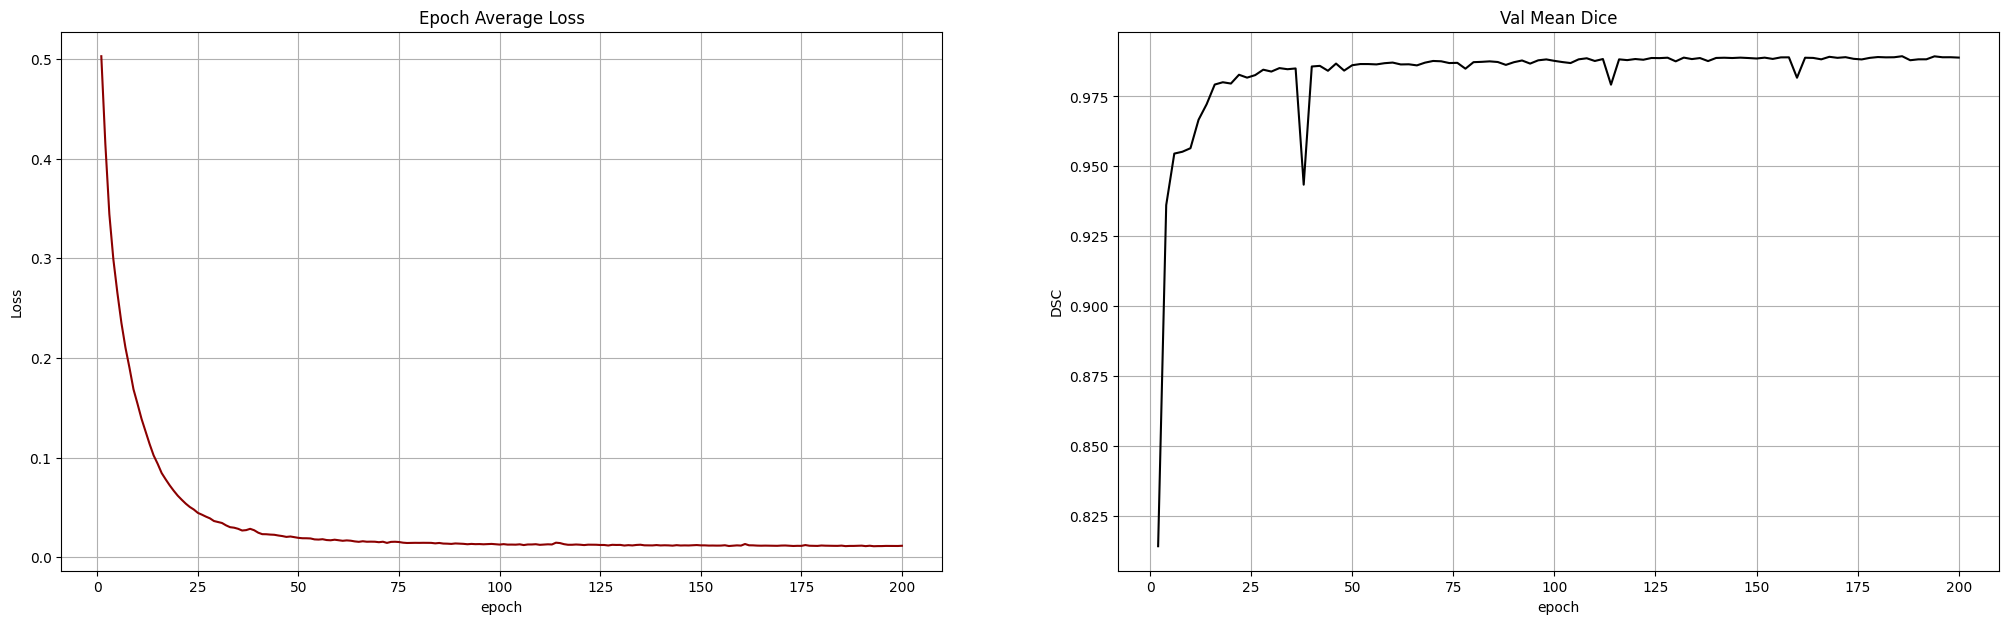

In [9]:
max_epochs = 200
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

# Post-processing identique
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=2)])
post_label = Compose([AsDiscrete(to_onehot=2)])

# Mixed precision
from tqdm import tqdm
scaler = torch.amp.GradScaler()

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    # Ajout d'une barre de progression
    for batch_data in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)

        optimizer.zero_grad()

        # Mixed precision training
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # Validation (identique)
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)

                # Sliding window inference
                val_outputs = sliding_window_inference(
                    val_inputs,
                    (96, 96, 96),
                    1,
                    model
                )

                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                dice_metric(y_pred=val_outputs, y=val_labels)

            # Calcul de la métrique Dice
            metric = dice_metric.aggregate().item()
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_metric_model.pth")
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )

# Téléchargement et visualisation
from google.colab import files
files.download('best_metric_model.pth')

plt.figure("train", (25,7))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.plot(x, y, color='darkred')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.ylabel("DSC")
plt.xlabel("epoch")
plt.grid(True)
plt.plot(x, y, color='black')
plt.show()

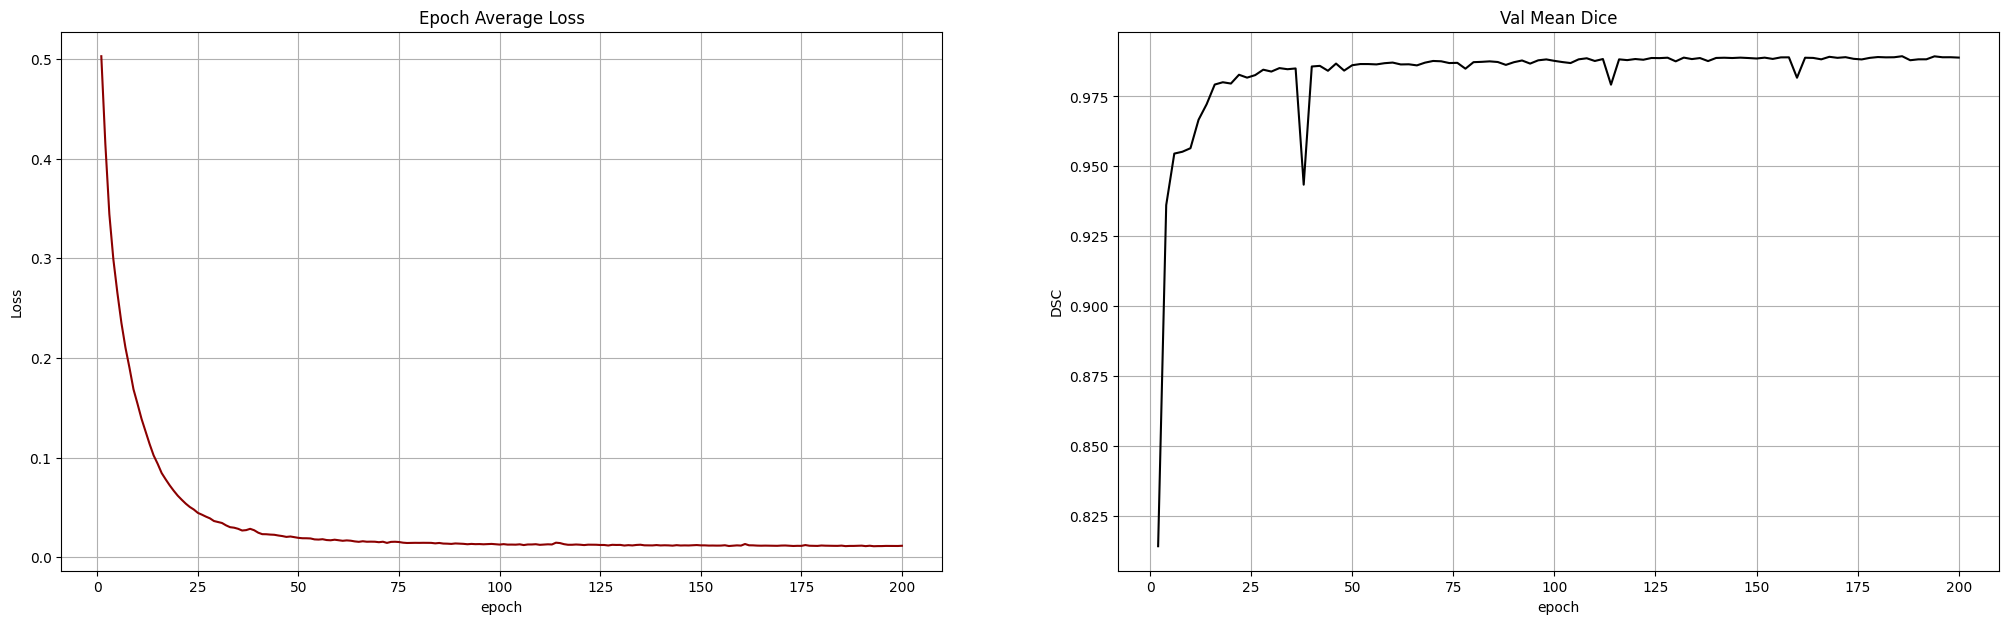

In [10]:
plt.figure("train", (25,7))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.plot(x, y, color='darkred')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.ylabel("DSC")
plt.xlabel("epoch")
plt.grid(True)
plt.plot(x, y, color='black')
plt.show()

In [11]:
test_ds = Dataset(data=test_files, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=1)

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=val_transforms,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=False,
        to_tensor=True,
    ),
    AsDiscreted(keys="pred", argmax=True, to_onehot=2),
    SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
])

Traitement de l'image de test n°1
Nombre de voxels dans le masque prédit: 1717689.0
Nombre de voxels dans le masque de référence: 1716484
Différence de voxels: 1205.0
TP: 1683508, FP: 34181, FN: 32976, TN: 3945055
Traitement de l'image de test n°2
Nombre de voxels dans le masque prédit: 950598.0
Nombre de voxels dans le masque de référence: 959835
Différence de voxels: -9237.0
TP: 928801, FP: 21797, FN: 31034, TN: 4714088
Traitement de l'image de test n°3
Nombre de voxels dans le masque prédit: 1737355.0
Nombre de voxels dans le masque de référence: 1744650
Différence de voxels: -7295.0
TP: 1714918, FP: 22437, FN: 29732, TN: 4509319
Traitement de l'image de test n°4
Nombre de voxels dans le masque prédit: 768824.0
Nombre de voxels dans le masque de référence: 783962
Différence de voxels: -15138.0
TP: 756203, FP: 12621, FN: 27759, TN: 5479823
Traitement de l'image de test n°5
Nombre de voxels dans le masque prédit: 1366581.0
Nombre de voxels dans le masque de référence: 1373493
Différen

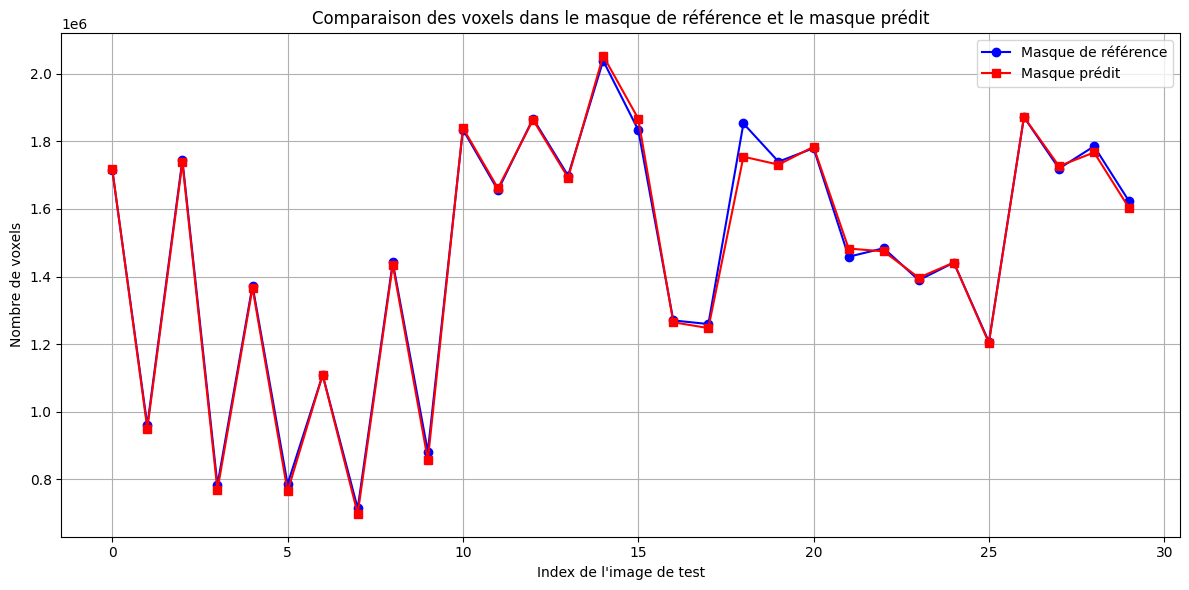

In [12]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

from monai.transforms import LoadImaged, AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

# Charger le modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = swinUnet_t_3D(hidden_dim=48, layers=[2, 2, 6, 2], heads=[3, 6, 12, 24], in_channel=1, num_classes=2, window_size=3).to(device)
model.load_state_dict(torch.load("best_metric_model.pth", map_location=device))
model.eval()

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Listes pour stocker les résultats
reference_voxels = []
predicted_voxels = []
TP_list = []
FP_list = []
FN_list = []
TN_list = []

# Parcourir les données de test
for i, test_data in enumerate(test_loader):
    print(f"Traitement de l'image de test n°{i + 1}")
    test_inputs, test_labels = test_data["image"].to(device), test_data["label"].to(device)

    # Inférence avec sliding window
    with torch.no_grad():
        test_outputs = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)

    # Post-traitement des sorties
    test_outputs = [post_pred(i) for i in decollate_batch(test_outputs)]

    # Convertir les masques en numpy arrays et supprimer les dimensions supplémentaires
    predicted_mask = test_outputs[0][1].cpu().numpy()
    predicted_mask = np.squeeze(predicted_mask)  # Supprimer les dimensions supplémentaires
    reference_mask = (test_labels[0] == 1).cpu().numpy().astype(np.uint8)
    reference_mask = np.squeeze(reference_mask)  # Supprimer les dimensions supplémentaires

    # Redimensionner le masque prédit à la taille du masque de référence
    if predicted_mask.shape != reference_mask.shape:
        zoom_factors = np.array(reference_mask.shape) / np.array(predicted_mask.shape)
        predicted_mask = scipy.ndimage.zoom(predicted_mask, zoom_factors, order=0)
        predicted_mask = (predicted_mask > 0.5).astype(np.int32)  # Re-binariser après redimensionnement

    # Calculer le nombre de voxels
    num_voxels_predicted = np.sum(predicted_mask)
    num_voxels_reference = np.sum(reference_mask)

    reference_voxels.append(num_voxels_reference)
    predicted_voxels.append(num_voxels_predicted)

    # Calcul des métriques (après le redimensionnement)
    TP = np.logical_and(predicted_mask == 1, reference_mask == 1).sum()
    FP = np.logical_and(predicted_mask == 1, reference_mask == 0).sum()
    FN = np.logical_and(predicted_mask == 0, reference_mask == 1).sum()
    TN = np.logical_and(predicted_mask == 0, reference_mask == 0).sum()

    TP_list.append(TP)
    FP_list.append(FP)
    FN_list.append(FN)
    TN_list.append(TN)

    print(f"Nombre de voxels dans le masque prédit: {num_voxels_predicted}")
    print(f"Nombre de voxels dans le masque de référence: {num_voxels_reference}")
    print(f"Différence de voxels: {num_voxels_predicted - num_voxels_reference}")
    print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")

# Calcul des métriques globales
total_TP = np.sum(TP_list)
total_FP = np.sum(FP_list)
total_FN = np.sum(FN_list)
total_TN = np.sum(TN_list)

precision = total_TP / (total_TP + total_FP + 1e-8)
recall = total_TP / (total_TP + total_FN + 1e-8)

print("\n--- Résultats globaux ---")
print(f"Précision : {precision:.4f} | Rappel : {recall:.4f}")

# Affichage du graphe comparatif
plt.figure(figsize=(12, 6))
x = np.arange(len(test_files))

plt.plot(x, reference_voxels, label="Masque de référence", marker='o', color='blue')
plt.plot(x, predicted_voxels, label="Masque prédit", marker='s', color='red')

plt.xlabel("Index de l'image de test")
plt.ylabel("Nombre de voxels")
plt.title("Comparaison des voxels dans le masque de référence et le masque prédit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 17:50:34,018 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


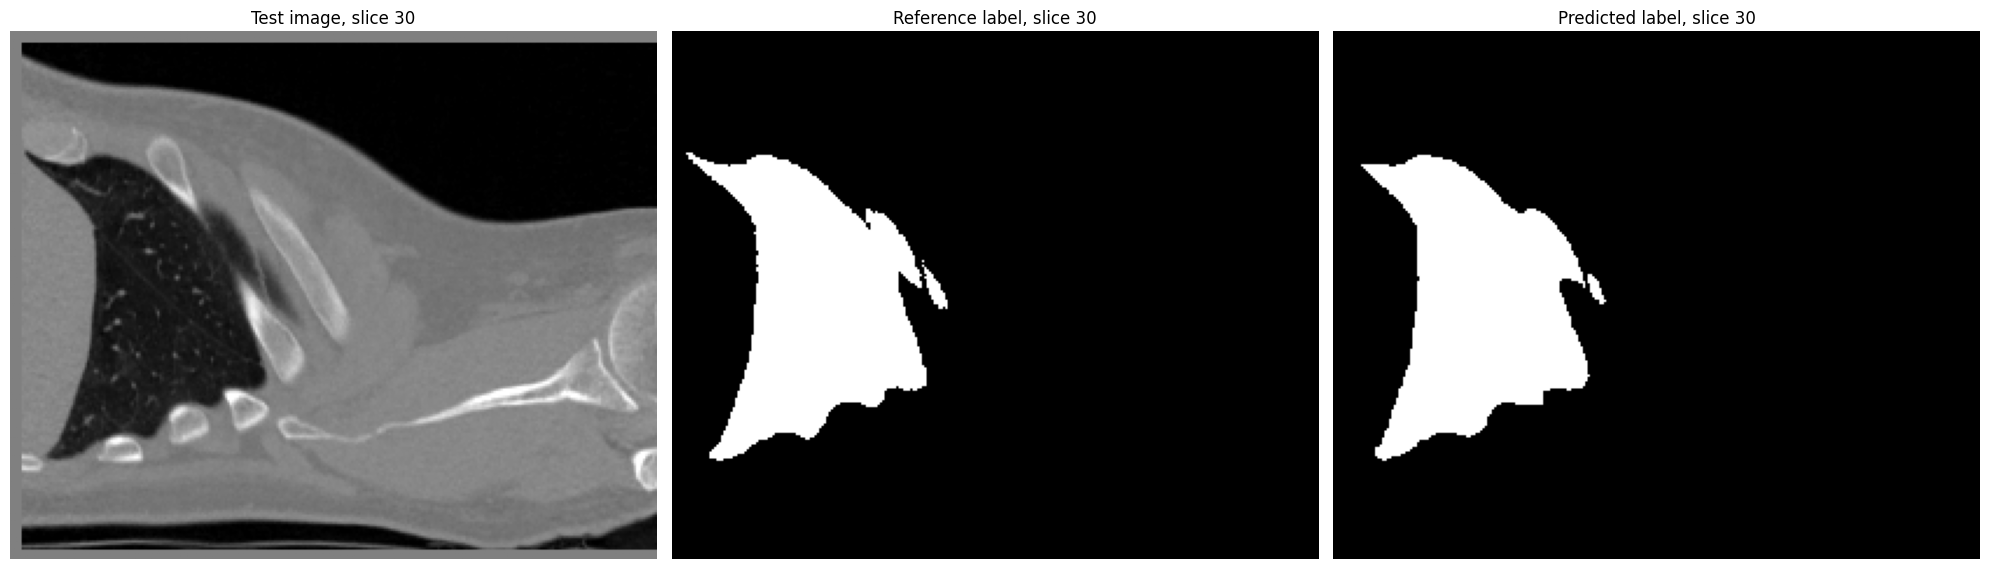

In [13]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 30
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 17:50:55,209 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


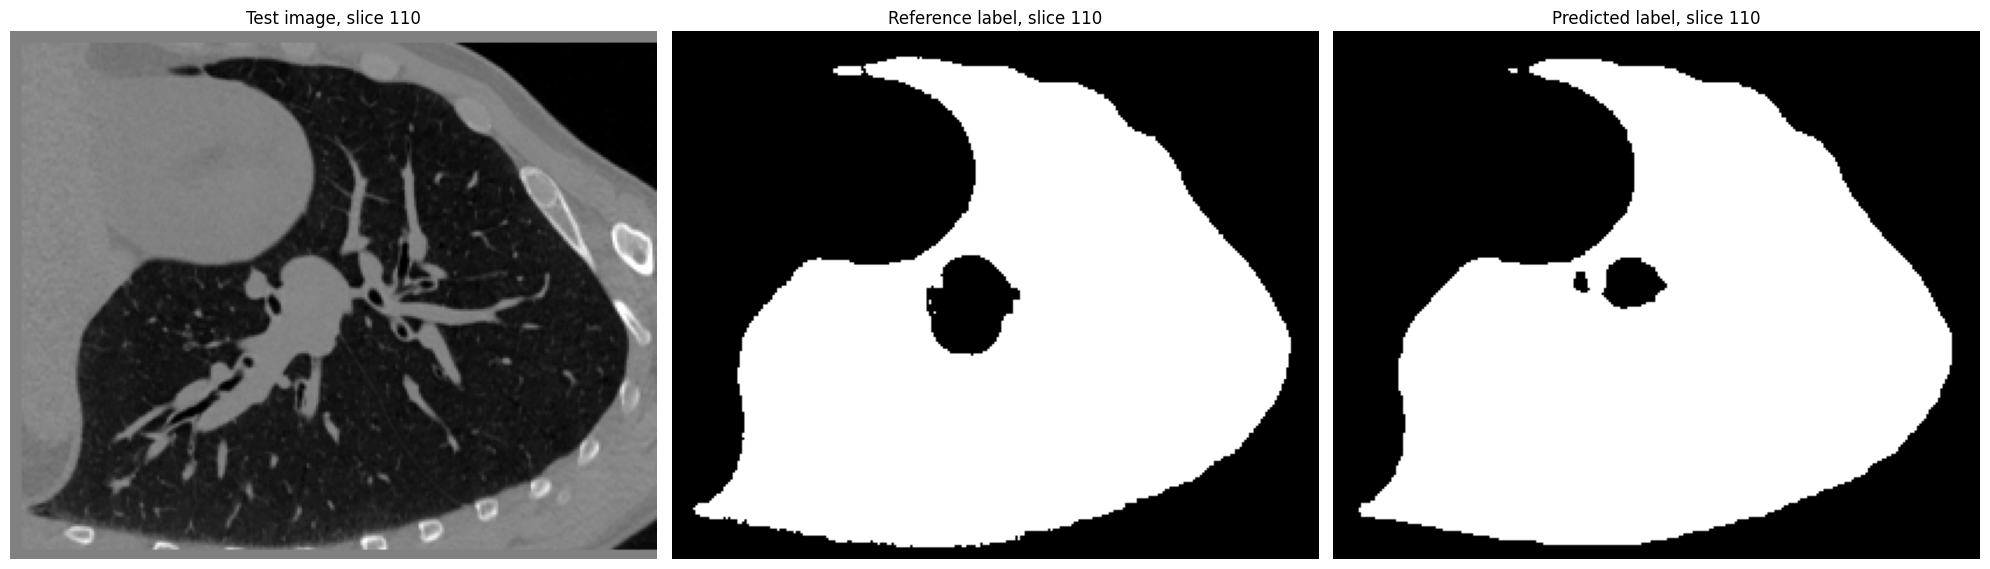

In [14]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 110
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 17:51:13,191 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


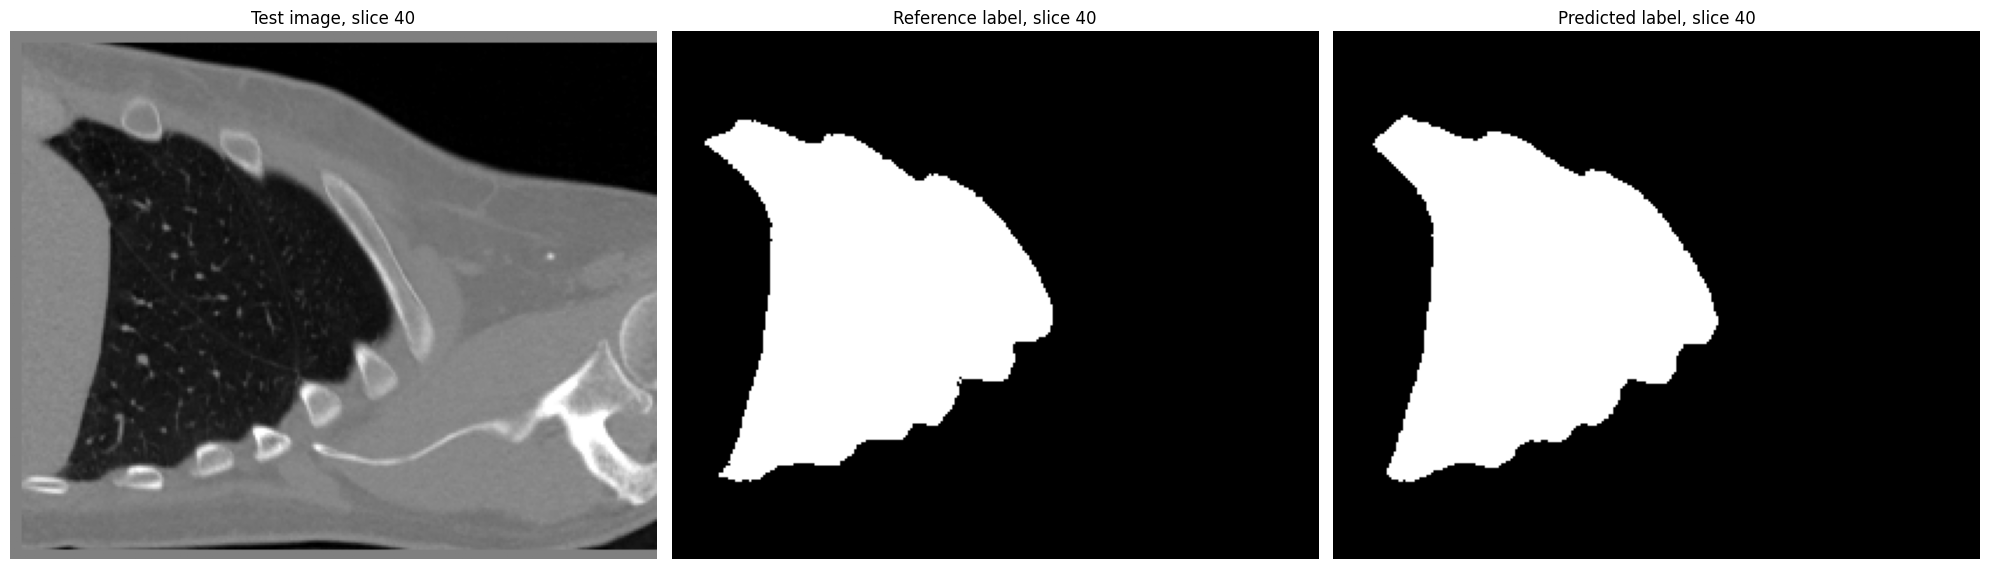

In [15]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 40
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 17:53:58,664 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


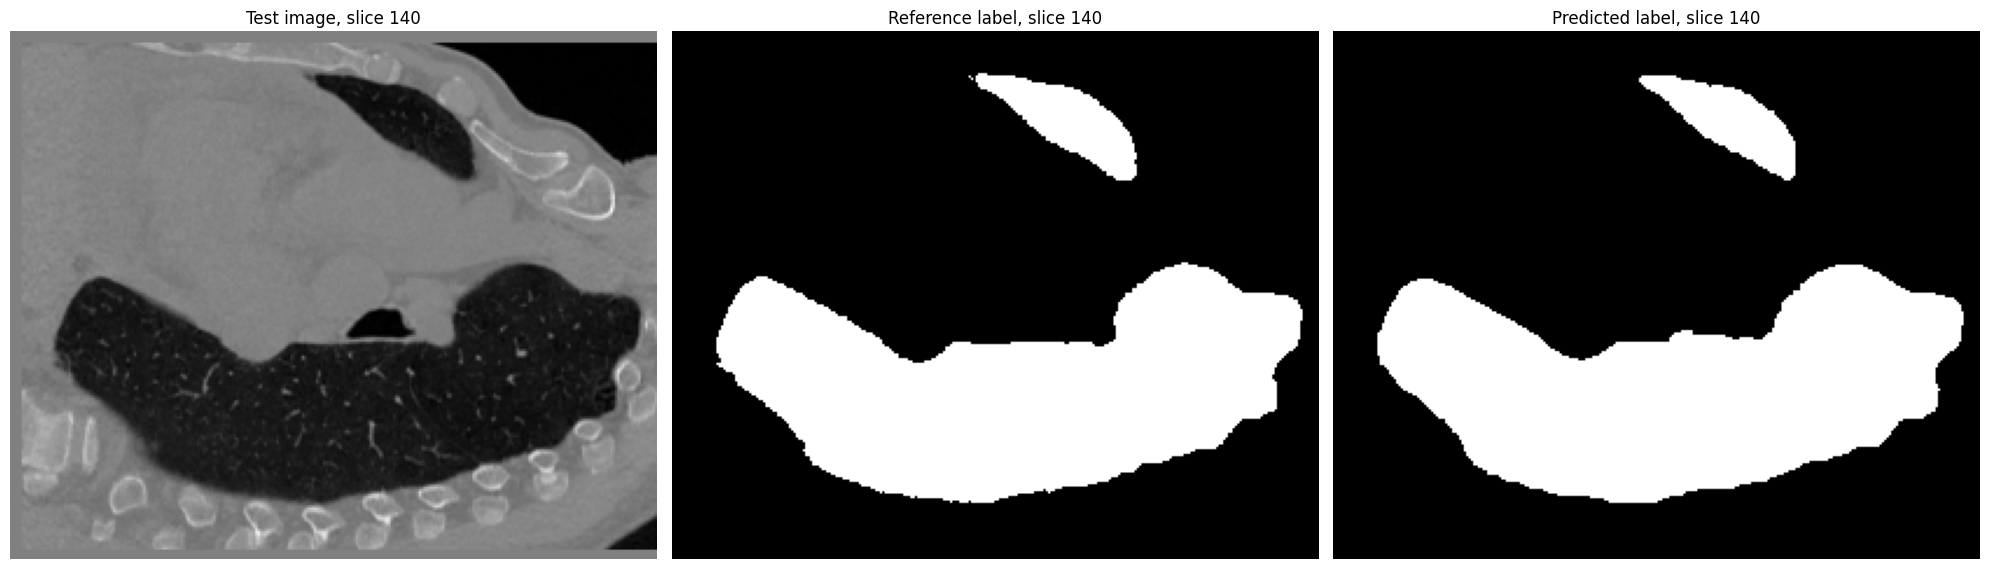

In [19]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 140
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()